# import

In [9]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


# 乱数の固定

In [10]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# （可能なら）GPUの利用

In [11]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


# 汎用関数の定義

## func show_images_labels

In [12]:
# イメージとラベル表示
def show_images_labels(loader, classes, net, device):
    # データローダーから最初の1セットを取得する
    for images, labels in loader:
        break
    # 表示数は50個とバッチサイズのうち小さい方
    n_size = min(images.size(0), 50)

    if net is not None:
        # デバイスの割り当て
        inputs = images.to(device)
        labels = labels.to(device)

      # 予測計算
        outputs = net(inputs)
        predicted = torch.max(outputs,1)[1]
        #images = images.to('cpu')

    # 最初のn_size個の表示
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # netがNoneでない場合は、予測結果もタイトルに表示する
        if net is not None:
            predicted_name = classes[predicted[i]]
            # 正解かどうかで色分けをする
            if label_name == predicted_name:
                c = 'g'
            else:
                c = 'r'
            ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # netがNoneの場合は、正解ラベルのみ表示
        else:
            ax.set_title(label_name, fontsize=20)
        # TensorをNumPyに変換
        image_np = images[i].numpy().copy()
        #print(image_np.shape)
        # 軸の順番変更 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 値の範囲を[-1, 1] -> [0, 1]に戻す
        img = (img + 1)/2
        # 結果表示
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


## func evaluate_history

In [13]:
def evaluate_history(history):
    print(f'初期状態: 損失: {history[0, 3]:.5f} 精度: {history[0, 4]:.5f}') 
    print(f'最終状態: 損失: {history[-1, 3]:.5f} 精度: {history[-1, 4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(9, 8))
    plt.plot(history[:, 0], history[:, 1], 'r', label='train')
    plt.plot(history[:, 0], history[:, 3], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Learning Curve (Loss)')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,8))
    plt.plot(history[:, 0], history[:, 2], 'r', label='train')
    plt.plot(history[:, 0], history[:, 4], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Learning Curve (Accuracy)')
    plt.grid()
    plt.legend()
    plt.show()


# データ準備

## Transformsの定義

In [14]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

## データセットの定義

In [16]:
data_root = './data'

# 元になるデータセット
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)

# データを分割するためのランダムなインデックスを生成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


45000
5000
10000


## データローダーの定義

In [17]:
# from torch.utils.data import Dataloader

batch_size = 100

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])


## 正解ラベルの変換規則

In [18]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 最初の50個の表示

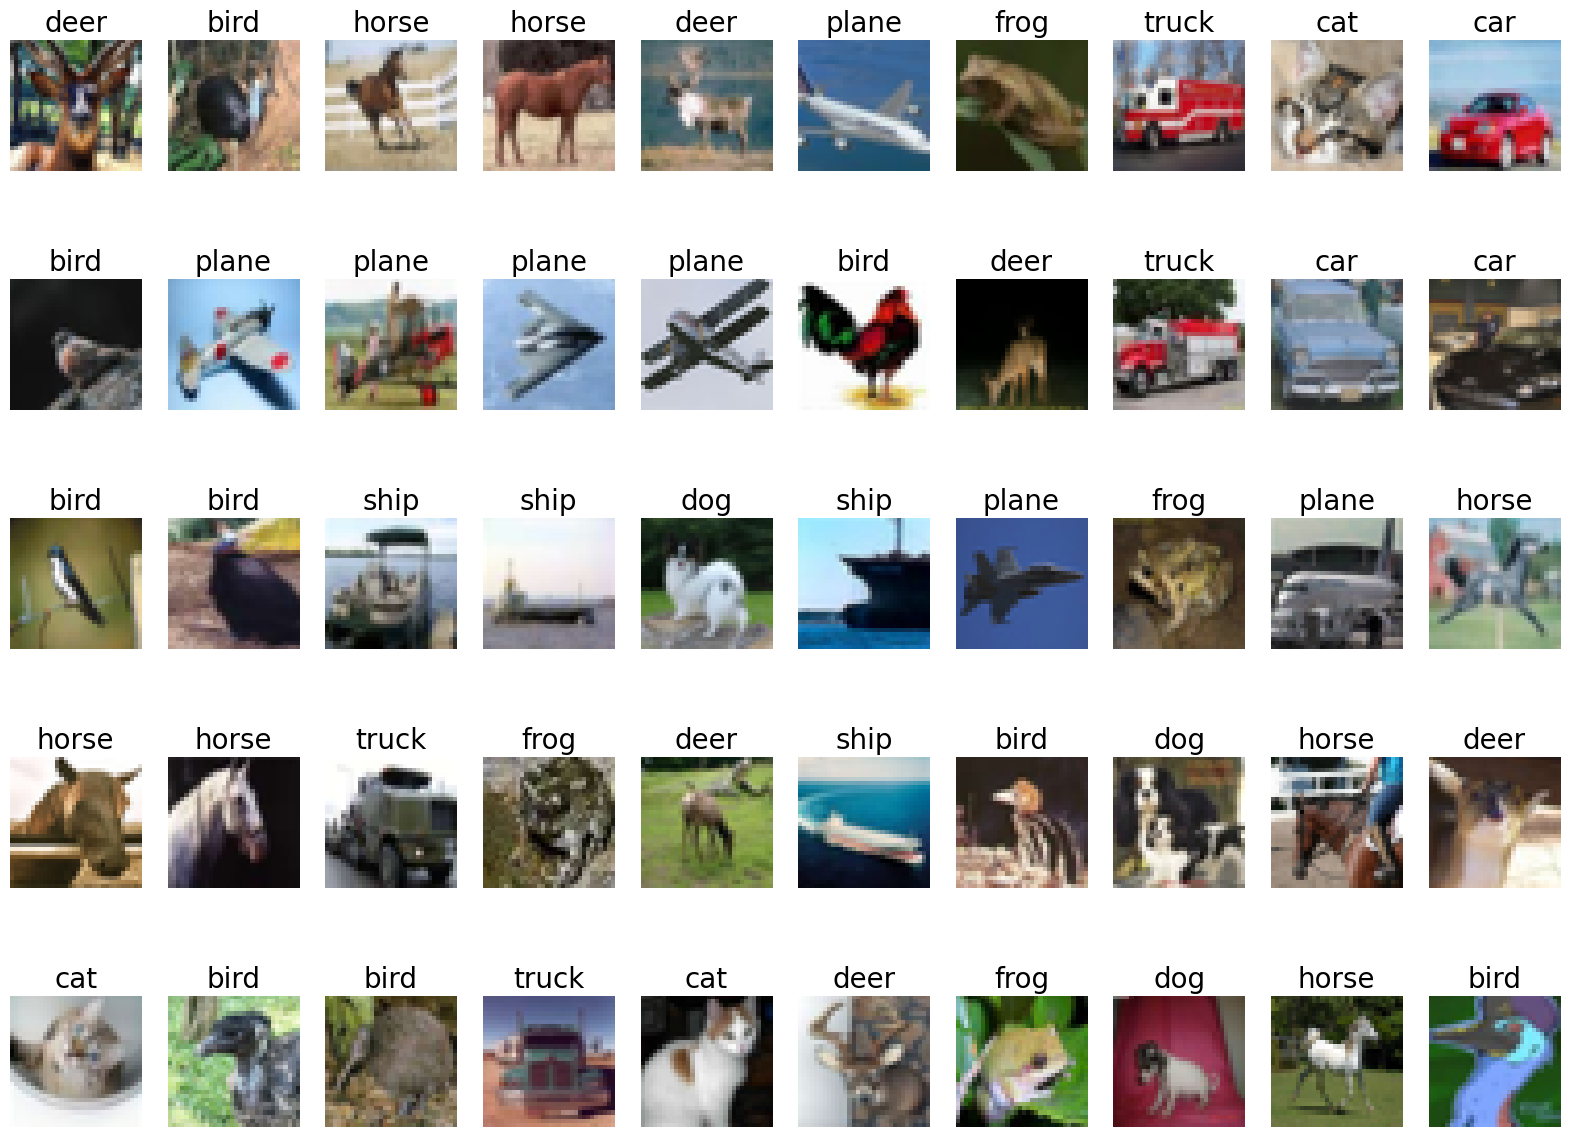

In [ ]:
show_images_labels(train_loader, classes, None, None)


# CNN_v2